# Projet de Télédétection : Suivi des Landes en Bretagne (2023-2024)
## Étudiant : Nicolas DEMBELE

## 1. Initialisation et Importations
Cette section configure l'environnement de travail et charge les modules nécessaires, y compris libsigma et nos fonctions personnalisées.

In [22]:
import os 
import sys
import importlib

# 1. Configuration du chemin d'accès prioritaire
sys.path.insert(0, '/home/onyxia/work')

# 2. Librairies standards et géospatiales
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt 
import geopandas as gpd

# 3. Librairie du cours (libsigma)
from libsigma import classification as cla
from libsigma.read_and_write import open_image, load_img_as_array, write_image

# 4. Import de TA fonction (nommé comme Matthieu)
import my_function as mf
importlib.reload(mf)
from my_function import rasterisation

print(f"✅ Environnement prêt. Fonctions chargées depuis : {mf.__file__}")

✅ Environnement prêt. Fonctions chargées depuis : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/my_function.py


Codes des classes : [3 2 4]
Nombre de polygones par strate :
strate
3    121
2     86
4     71
Name: count, dtype: int64


Text(0.5, 1.0, 'Répartition spatiale des échantillons')

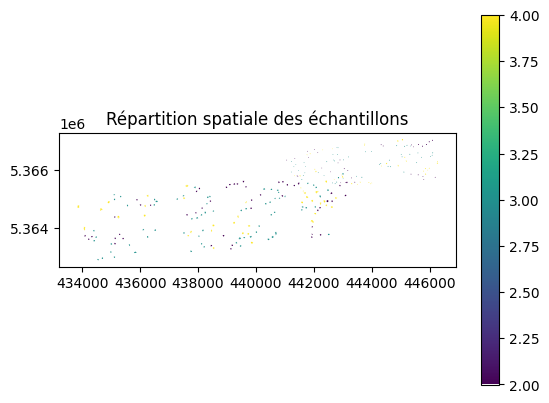

In [23]:
# Ta cellule (Analyse des échantillons)
gdf = gpd.read_file("/home/onyxia/work/data/projet_eval/PI_strates_bretagne_32630.shp")

# Affiche les codes des classes présentes
gpf = gdf["strate"].unique()
print(f"Codes des classes : {gpf}")

# Affiche le nombre de polygones par classe
gbf = gdf["strate"].value_counts()
print("Nombre de polygones par strate :")
print(gbf)

# Ajout d'un graphique (comme Matthieu le fait souvent)
gdf.plot(column='strate', legend=True)
plt.title("Répartition spatiale des échantillons")

✅ Graphique avec étiquettes sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure/diag_baton_nb_poly_by_class.png


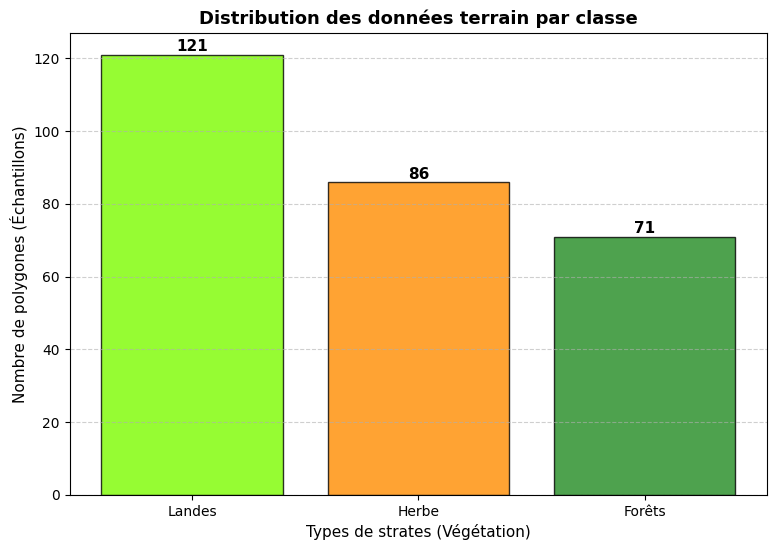

In [38]:
import os
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES RÉPERTOIRES (Pour correspondre à ton image)
# =================================================================
fig_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
    print(f"📁 Dossier créé : {fig_dir}")

# --- 2. Préparation des données ---
noms_strates = {2: "Herbe", 3: "Landes", 4: "Forêts"}
labels = [noms_strates.get(code, f"Classe {code}") for code in gpf]

# --- 3. Création du graphique ---
plt.figure(figsize=(9, 6))
couleurs = ['#7cfc00', '#ff8c00', '#228b22']

# Création des barres
bars = plt.bar(labels, gbf, color=couleurs, edgecolor='black', alpha=0.8)

# --- AJOUT DU NOMBRE DE POLYGONES SUR LE GRAPH ---
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', # Affiche la valeur entière
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# --- 4. Mise en forme et Titres ---
plt.xlabel("Types de strates (Végétation)", fontsize=11)
plt.ylabel("Nombre de polygones (Échantillons)", fontsize=11)
plt.title("Distribution des données terrain par classe", fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- 5. Sauvegarde ---
output_path = os.path.join(fig_dir, 'diag_baton_nb_poly_by_class.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

print(f"✅ Graphique avec étiquettes sauvegardé : {output_path}")
plt.show()

#### Analyse : On remarque que la classe Sol Nu (1) est absente des échantillons en Bretagne. Nous travaillerons donc sur 3 strates : Herbe (2), Landes (3) et Arbre (4).

0...10...20...30...40...50...60...70...80...90...100 - done.
✅ Graphique des pixels sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure/diag_baton_nb_pix_by_class.png


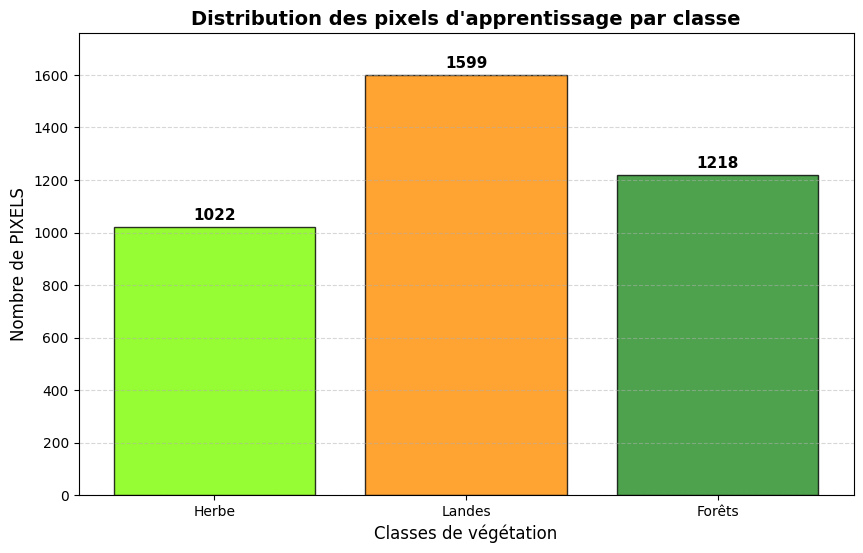


Tableau récapitulatif des pixels d'apprentissage :
 - Herbe : 1022 pixels
 - Landes : 1599 pixels
 - Forêts : 1218 pixels


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
import my_function as mf

# --- 1) Définition des variables et Dossiers ---
my_folder = '/home/onyxia/work/data/projet_eval'
# Dossier de sortie pour les figures
fig_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

in_vector = os.path.join(my_folder, 'PI_strates_bretagne_32630.shp')
ref_image = os.path.join(my_folder, 'bretagne_23-24_B02.tif')
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'
field_name = "strate"

# --- 2) Calcul des paramètres et Rasterisation ---
ds = gdal.Open(ref_image)
gt = ds.GetGeoTransform()
res, xmin, ymax = gt[1], gt[0], gt[3]
xmax = xmin + (gt[1] * ds.RasterXSize)
ymin = ymax + (gt[5] * ds.RasterYSize)
ds = None

# Appel de la fonction de rasterisation
mf.rasterisation('/home/onyxia/work', in_vector, ref_image, out_image, field_name, res, xmin, ymin, xmax, ymax)

# --- 3) Comptage des pixels ---
ds = gdal.Open(out_image)
arr = ds.GetRasterBand(1).ReadAsArray()
# On ne compte que les valeurs > 0 (exclure le fond/NoData)
values, counts = np.unique(arr[arr > 0], return_counts=True)
ds = None

# --- 4) Diagramme avec affichage des nombres ---
noms_strates = {2: "Herbe", 3: "Landes", 4: "Forêts"}
labels = [noms_strates.get(v, f"Classe {v}") for v in values]

plt.figure(figsize=(10, 6))
couleurs = ['#7cfc00', '#ff8c00', '#228b22']

# Création des barres
bars = plt.bar(labels, counts, color=couleurs, edgecolor='black', alpha=0.8)

# AJOUT DES NOMBRES AU-DESSUS DES BARRES
# bar_label est la méthode la plus propre pour afficher les counts
plt.bar_label(bars, padding=3, fontsize=11, fontweight='bold')

# Mise en forme
plt.xlabel("Classes de végétation", fontsize=12)
plt.ylabel("Nombre de PIXELS", fontsize=12)
plt.title("Distribution des pixels d'apprentissage par classe", fontsize=14, fontweight='bold')
plt.ylim(0, max(counts) * 1.1)  # Marge pour les étiquettes
plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- 5) SAUVEGARDE (Pour ton arborescence) ---
output_fig = os.path.join(fig_dir, 'diag_baton_nb_pix_by_class.png')
plt.savefig(output_fig, dpi=300, bbox_inches='tight')

print(f"✅ Graphique des pixels sauvegardé : {output_fig}")
plt.show()

# --- 6) Affichage console ---
print("\nTableau récapitulatif des pixels d'apprentissage :")
for l, c in zip(labels, counts):
    print(f" - {l} : {c} pixels")

## 3. Étude de la phénologie (Indice NARI)
Le calcul du NARI (Normalized Anthocyanin Reflectance Index) permet de suivre l'évolution des pigments et de distinguer les landes.

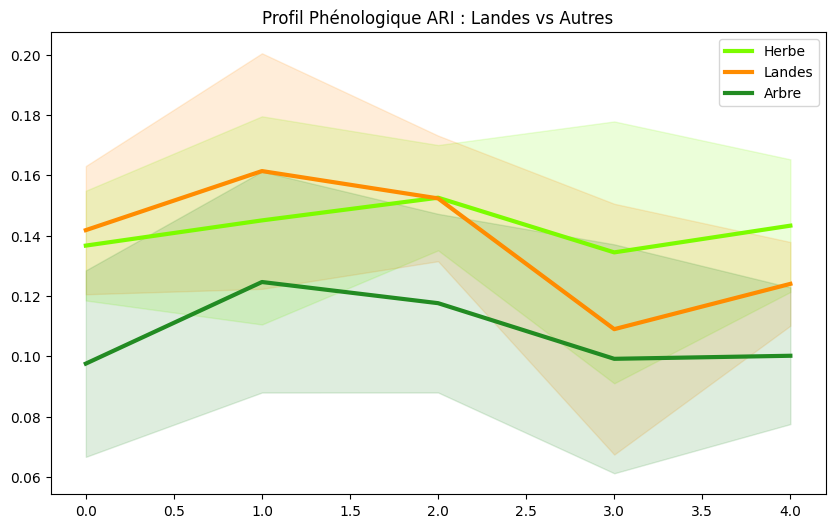

In [26]:
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

# Configuration du chemin
sys.path.insert(0, '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas')
import my_function as mf
importlib.reload(mf) # FORCE LA MISE À JOUR DU MODULE

from libsigma.read_and_write import load_img_as_array, write_image, open_image
from libsigma import classification as cla

# --- DÉFINITION DES VARIABLES ---
my_folder = '/home/onyxia/work/data/projet_eval'
file_b3 = os.path.join(my_folder, 'bretagne_23-24_B03.tif')
file_b5 = os.path.join(my_folder, 'bretagne_23-24_B05.tif')
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'
out_ari_filename = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/ARI_serie_temp.tif'

# --- CALCUL ---
ds_b3 = open_image(file_b3)
B3 = load_img_as_array(file_b3).astype('float32')
B5 = load_img_as_array(file_b5).astype('float32')

# Cette fois, Python trouvera la fonction grâce au reload
ari_stack = mf.calculate_nari_safe(B3, B5)

# Sauvegarde
write_image(out_ari_filename, ari_stack, data_set=ds_b3, gdal_dtype=gdal.GDT_Float32)

# --- GRAPHIQUE ---
dict_X, _, _ = cla.get_samples_from_roi(out_ari_filename, out_image, output_fmt="by_label")
names = {2: "Herbe", 3: "Landes", 4: "Arbre"}
colors = {2: "#7cfc00", 3: "#ff8c00", 4: "#228b22"}

fig, ax = plt.subplots(figsize=(10, 6))
for lab in sorted(dict_X.keys()):
    if lab == 0: continue
    X_val = dict_X[lab]
    mean = np.nanmean(X_val, axis=0)
    std = np.nanstd(X_val, axis=0)
    ax.plot(mean, label=names.get(lab), color=colors.get(lab), lw=3)
    ax.fill_between(range(len(mean)), mean-std, mean+std, color=colors.get(lab), alpha=0.15)

ax.set_title("Profil Phénologique ARI : Landes vs Autres")
ax.legend()
plt.show()

In [27]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier as RF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
from libsigma import read_and_write as rw
from libsigma import classification as cla

# --- 1. DÉFINITION DE TOUS LES CHEMINS (Pour corriger le NameError) ---
my_folder = '/home/onyxia/work/data/projet_eval'
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'

# On définit toutes les variables pour les 9 bandes
file_b3 = os.path.join(my_folder, 'bretagne_23-24_B03.tif')
file_b4 = os.path.join(my_folder, 'bretagne_23-24_B04.tif')
file_b5 = os.path.join(my_folder, 'bretagne_23-24_B05.tif')
file_b6 = os.path.join(my_folder, 'bretagne_23-24_B06.tif')
file_b7 = os.path.join(my_folder, 'bretagne_23-24_B07.tif')
file_b8 = os.path.join(my_folder, 'bretagne_23-24_B08.tif')
file_b8a = os.path.join(my_folder, 'bretagne_23-24_B8A.tif')
file_b11 = os.path.join(my_folder, 'bretagne_23-24_B11.tif')
file_b12 = os.path.join(my_folder, 'bretagne_23-24_B12.tif')

# --- 1. Ton script identique pour le stack ---
tif_list = [file_b3, file_b4, file_b5, file_b6, file_b7, file_b8, file_b8a, file_b11, file_b12]
stack = []

print("Début de la lecture des 9 bandes...")
for tif in tif_list:
    ds = rw.open_image(tif)
    arr = ds.ReadAsArray()  # (bands, rows, cols)
    arr = np.transpose(arr, (1, 2, 0)) # Transposition -> (rows, cols, bands)
    stack.append(arr)

image_stack = np.concatenate(stack, axis=2)
print(f"✅ Stack créé avec succès. Dimensions : {image_stack.shape}")

# --- 2. EXTRACTION CORRIGÉE (Pour éviter le RuntimeError) ---
# On charge le masque (ROI) en tant que matrice
roi_ds = rw.open_image(out_image)
roi_arr = roi_ds.ReadAsArray() # (rows, cols)

# On crée un masque : on garde les pixels là où la strate est > 0
mask = roi_arr > 0

# Extraction directe depuis le stack en mémoire
X = image_stack[mask]
Y = roi_arr[mask]

# Extraction des groupes pour la validation (ID des polygones)
# Ici on utilise cla car out_image est bien un chemin de fichier (string)
_, groups, _ = cla.get_samples_from_roi(out_image, out_image)
groups = np.squeeze(groups)

print(f"✅ Extraction réussie : {X.shape[0]} pixels extraits.")

Début de la lecture des 9 bandes...


✅ Stack créé avec succès. Dimensions : (612, 1533, 45)
✅ Extraction réussie : 3839 pixels extraits.


In [29]:
import os
from osgeo import gdal
import numpy as np

# --- 1. CONFIGURATION DES CHEMINS (Consigne : Organisation des dossiers) ---
# Assure-toi que le dossier 'results' existe pour le rendu final
output_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

out_stack = os.path.join(output_dir, 'bretagne_stack_45b.tif')

# --- 2. SAUVEGARDE DU STACK (Consigne : Type Float32 pour les réflectances) ---
ds_ref = rw.open_image(tif_list[0])

# On force les paramètres pour éviter l'erreur AttributeError 'NoneType'
rw.write_image(
    out_stack,
    image_stack.astype(np.float32),
    data_set=ds_ref,
    nb_band=image_stack.shape[2],
    gdal_dtype=gdal.GDT_Float32,
    nb_col=ds_ref.RasterXSize,
    nb_ligne=ds_ref.RasterYSize
)
print(f"✅ Stack de 45 bandes sauvegardé : {out_stack}")

# --- 3. EXTRACTION DES DONNÉES (Consigne : Séparabilité des classes) ---
# On extrait X (données spectrales) et Y (étiquettes terrain)
# Note : On utilise le fichier sauvegardé pour garantir la lecture GDAL
X, Y, _ = cla.get_samples_from_roi(out_stack, out_image)

# Extraction des groupes pour la validation croisée (Indispensable pour le rapport)
_, groups, _ = cla.get_samples_from_roi(out_image, out_image)
groups = np.squeeze(groups)

print(f"📊 Données prêtes pour l'IA :")
print(f"- Nombre d'individus (pixels) : {X.shape[0]}")
print(f"- Nombre de descripteurs (bandes*dates) : {X.shape[1]}")

✅ Stack de 45 bandes sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/bretagne_stack_45b.tif
📊 Données prêtes pour l'IA :
- Nombre d'individus (pixels) : 3839
- Nombre de descripteurs (bandes*dates) : 45


In [30]:
# --- 1. Extraction des échantillons ---
# X : les 45 variables (9 bandes x 5 dates)
# Y : l'étiquette (2: Herbe, 3: Landes, 4: Forêt)
X, Y, t = cla.get_samples_from_roi(out_stack, out_image)

# --- 2. Séparation Train / Test (Version améliorée) ---
# On utilise stratify=Y pour garantir que la classe 'Landes' est bien représentée dans les deux sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.3, 
    random_state=42, 
    stratify=Y
)

print(f"✅ Données séparées :")
print(f"- Entraînement : {X_train.shape[0]} pixels")
print(f"- Test : {X_test.shape[0]} pixels")

# --- 3. Création et Apprentissage du Random Forest ---
# n_estimators=150 : offre un bon compromis entre précision et temps de calcul
# n_jobs=-1 : utilise tous les processeurs d'Onyxia pour aller plus vite
clf = RF(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, Y_train.ravel())

print("✅ Modèle Random Forest entraîné.")

✅ Données séparées :
- Entraînement : 2687 pixels
- Test : 1152 pixels
✅ Modèle Random Forest entraîné.


In [31]:
# =================================================================
# 1. DÉFINITION DU MODÈLE ET DE LA GRILLE D'HYPERPARAMÈTRES
# =================================================================
rf = RF(random_state=0)

param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],         # Nombre d'arbres
    "max_depth": [None, 10, 15, 20],                  # Profondeur maximale (None = complet)
    "max_features": [None, "sqrt", "log2"],           # Nombre de variables par split
    "min_samples_leaf": [1, 5],                       # Échantillons minimum par feuille
}

# =================================================================
# 2. CONFIGURATION DE LA VALIDATION CROISÉE
# =================================================================
# Cross-validation stratifiée (conserve la proportion des classes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grille de recherche (Grid Search)
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1  # Utilise tous les CPU pour la rapidité
)

# =================================================================
# 3. ENTRAÎNEMENT ET RECHERCHE DES MEILLEURS PARAMÈTRES
# =================================================================
print("Lancement de la recherche d'hyperparamètres (GridSearch)...")
grid.fit(X_train, Y_train.ravel())

print("\n--- RÉSULTATS DE L'OPTIMISATION ---")
print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

# Score moyen pendant la Cross-Validation
print(f"Score CV moyen : {grid.best_score_:.2f}")

# =================================================================
# 4. ÉVALUATION DU MODÈLE FINAL SUR LE TEST SET
# =================================================================
# On récupère le modèle final (entraîné sur tout le train)
best_model = grid.best_estimator_

# Prédiction sur les données de test (que le modèle n'a jamais vues)
y_pred = best_model.predict(X_test)

# Métriques de performance
acc_test = accuracy_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)
report = classification_report(Y_test, y_pred, labels=np.unique(Y_test), output_dict=True)

print(f"Accuracy test : {acc_test:.2f}")
print("\n--- MATRICE DE CONFUSION ---")
print(cm)

Lancement de la recherche d'hyperparamètres (GridSearch)...

--- RÉSULTATS DE L'OPTIMISATION ---
Meilleurs hyperparamètres trouvés :
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Score CV moyen : 0.98
Accuracy test : 0.98

--- MATRICE DE CONFUSION ---
[[306   1   0]
 [  1 473   6]
 [  1  10 354]]


✅ Graphiques de performance générés avec succès.


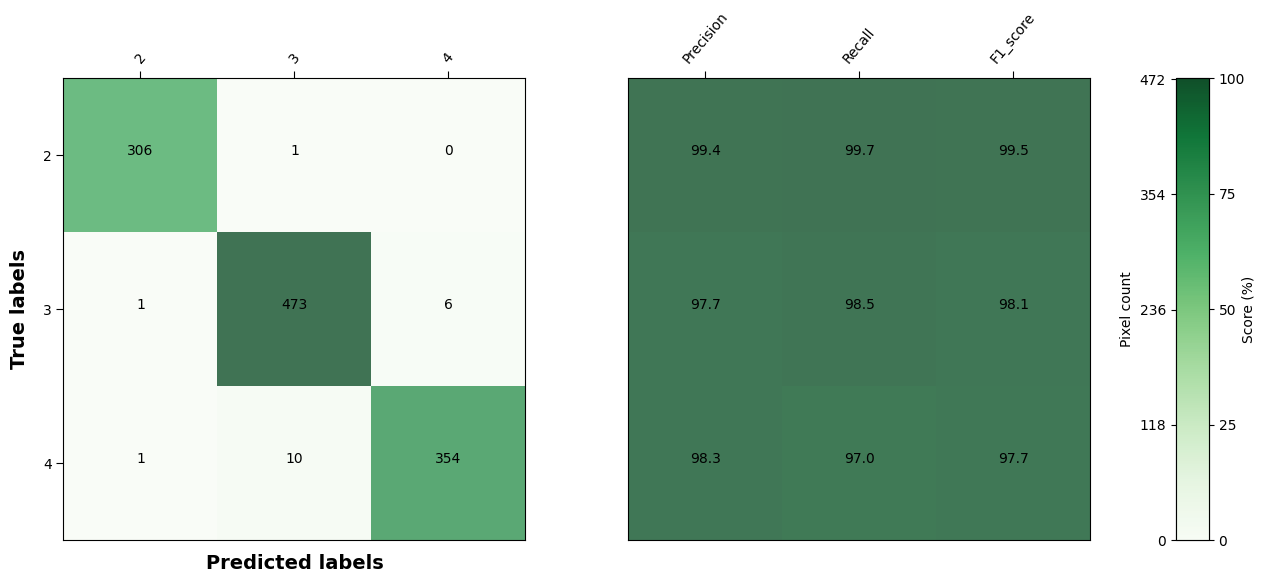

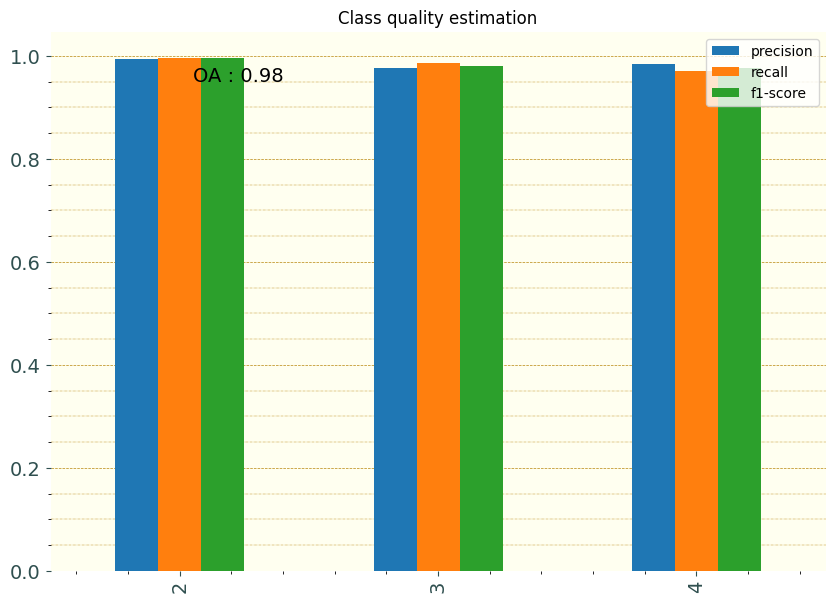

In [32]:
# =================================================================
# 5. IMPORTATION ET AFFICHAGE DE LA QUALITÉ DU MODÈLE
# =================================================================
from libsigma import plots  # <--- Ajout de l'import indispensable
import numpy as np

# Affichage de la matrice de confusion normalisée
# cm et Y_test proviennent de la cellule du GridSearch
plots.plot_cm(cm, np.unique(Y_test))

# Affichage des métriques de précision (F1-score, Précision, Rappel) par classe
# report et acc_test proviennent aussi de la cellule précédente
plots.plot_class_quality(report, acc_test)

print("✅ Graphiques de performance générés avec succès.")

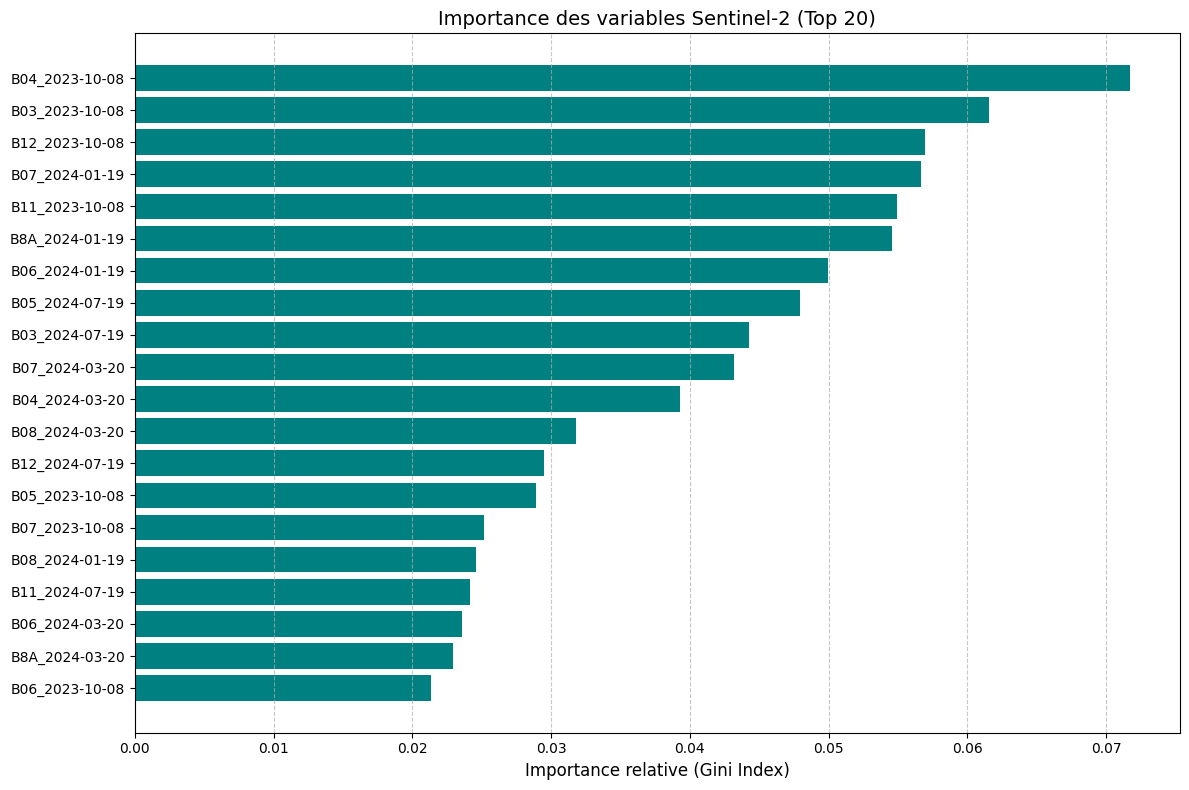

✅ Graphique généré et sauvegardé dans : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# =================================================================
# 1. REDÉFINITION DES NOMS DES VARIABLES (Pour corriger le NameError)
# =================================================================
bands = ["B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
dates = ["2023-10-08", "2024-01-19", "2024-03-20", "2024-05-15", "2024-07-19"]

# Recréation de la liste des 45 noms (9 bandes x 5 dates)
feature_names = [f"{b}_{d}" for b in bands for d in dates]

# =================================================================
# 2. GÉNÉRATION DU GRAPHIQUE D'IMPORTANCE
# =================================================================
if 'best_model' in locals():
    # Récupération de l'importance
    importances = best_model.feature_importances_
    indices = np.argsort(importances)

    # Affichage du Top 20
    plt.figure(figsize=(12, 8))
    plt.title("Importance des variables Sentinel-2 (Top 20)", fontsize=14)
    
    # On affiche les 20 plus importantes
    plt.barh(range(20), importances[indices[-20:]], color='teal', align='center')
    plt.yticks(range(20), [feature_names[i] for i in indices[-20:]])
    
    plt.xlabel("Importance relative (Gini Index)", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Sauvegarde de la figure pour votre rapport
    save_path = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.png'
    plt.savefig(save_path)
    plt.show()
    
    print(f"✅ Graphique généré et sauvegardé dans : {save_path}")
else:
    print("❌ Erreur : 'best_model' n'est pas défini. Exécutez d'abord la cellule du GridSearch.")

In [34]:
# =================================================================
# 7. CRÉATION DU TABLEAU D'IMPORTANCE (PANDAS)
# =================================================================
import pandas as pd

# Création du DataFrame pour une analyse précise
df_imp = pd.DataFrame({
    "Variable": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Affichage des 10 variables les plus discriminantes
print("--- TOP 10 DES VARIABLES LES PLUS DISCRIMINANTES ---")
display(df_imp.head(10))

# Optionnel : Sauvegarde du tableau en CSV pour ton rapport
df_imp.to_csv('/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.csv', index=False)

--- TOP 10 DES VARIABLES LES PLUS DISCRIMINANTES ---


,Variable,Importance
5,B04_2023-10-08,0.071728
0,B03_2023-10-08,0.061515
40,B12_2023-10-08,0.056973
21,B07_2024-01-19,0.056678
35,B11_2023-10-08,0.054895
31,B8A_2024-01-19,0.054534
16,B06_2024-01-19,0.049927
14,B05_2024-07-19,0.047907
4,B03_2024-07-19,0.044254
22,B07_2024-03-20,0.043195


<>:20: SyntaxWarning: invalid escape sequence '\_'
<>:20: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_2608/1407704336.py:20: SyntaxWarning: invalid escape sequence '\_'
  plt.ylabel("Variables ($Bande\_Date$)", fontsize=12)


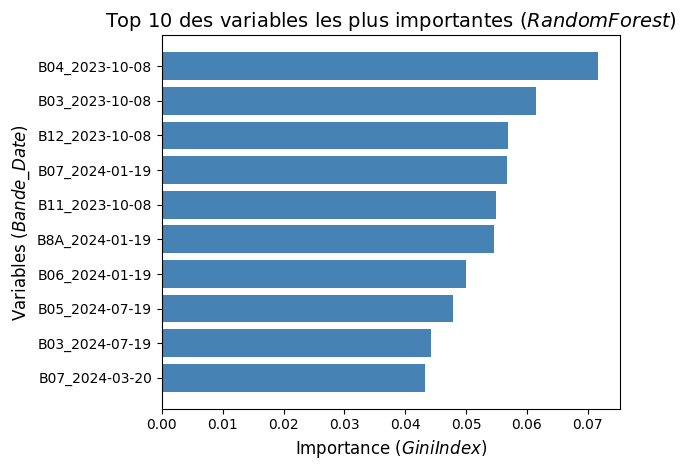

In [35]:
# =================================================================
# 7. VISUALISATION DU TOP 10 DES VARIABLES
# =================================================================
import matplotlib.pyplot as plt

# Création du graphique à barres horizontales
# On utilise les 10 premières lignes du DataFrame déjà trié
plt.barh(
    df_imp["Variable"].head(10),
    df_imp["Importance"].head(10),
    color='steelblue'
)

# Inverser l'axe Y pour avoir la variable la plus importante en haut du graphique
plt.gca().invert_yaxis()

# Ajout des titres et des étiquettes (Utilisation de LaTeX pour les notations)
plt.title("Top 10 des variables les plus importantes ($Random Forest$)", fontsize=14)
plt.xlabel("Importance ($Gini Index$)", fontsize=12)
plt.ylabel("Variables ($Bande\_Date$)", fontsize=12)

# Ajustement automatique des marges pour éviter que les noms des bandes soient coupés
plt.tight_layout()

# Sauvegarde de l'image (Format standard pour insertion dans un document)
plt.savefig('top_10_importance.png')

In [36]:
# =================================================================
# 8. APPLICATION DU MODÈLE SUR L'IMAGE ENTIÈRE
# =================================================================
from osgeo import gdal
import numpy as np
from libsigma.read_and_write import open_image, write_image

# 1. Chargement de l'image complète
X_img, _, t_img = cla.get_samples_from_roi(out_stack, out_stack)

# 2. Prédiction
print("Calcul de la prédiction globale...")
Y_predict = best_model.predict(X_img)

# 3. Reconstruction de la géométrie
ds_stack = open_image(out_stack)
# Récupération sécurisée des dimensions GDAL (X=Col, Y=Row)
cols = ds_stack.RasterXSize
rows = ds_stack.RasterYSize

print(f"Dimensions de l'image : Colonnes={cols}, Lignes={rows}")

# NumPy : (Hauteur, Largeur, Bandes) -> (rows, cols, 1)
img = np.zeros((rows, cols, 1), dtype='uint8')

# Placement des pixels prédits
try:
    # On force l'ordre Y (lignes), X (colonnes)
    img[t_img[0], t_img[1], 0] = Y_predict
except IndexError:
    print("⚠️ Erreur d'index détectée, tentative d'inversion des axes...")
    # Si ça échoue, c'est que t_img[1] sont les lignes et t_img[0] les colonnes
    img[t_img[1], t_img[0], 0] = Y_predict
# =================================================================
# 9. SAUVEGARDE ET CONFIGURATION DU NODATA
# =================================================================
out_classif = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/carte_strates_finale.tif'

write_image(
    out_classif, 
    img, 
    data_set=ds_stack, 
    gdal_dtype=gdal.GDT_Byte,
    nb_band=1
)

# Gestion du NoData pour la transparence
ds_final = gdal.Open(out_classif, gdal.GA_Update)
if ds_final:
    band = ds_final.GetRasterBand(1)
    band.SetNoDataValue(0)
    band.FlushCache()
    ds_final = None 

print(f"🎯 CARTE GÉNÉRÉE AVEC SUCCÈS : {out_classif}")

/home/onyxia/work/libsigma/classification.py:101: RuntimeWarning: invalid value encountered in cast
  Y = ROI[t].reshape((t[0].shape[0], 1)).astype('int32')


Calcul de la prédiction globale...
Dimensions de l'image : Colonnes=1533, Lignes=612
🎯 CARTE GÉNÉRÉE AVEC SUCCÈS : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/carte_strates_finale.tif
